In [61]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from figures_setup import *
from utils import set_color_code

# CRC cohort PDOX-seq

## Getting data from arrayExpress: E-MTAB-16585

In [63]:
# Download data from arrayExpress and reassemble anndata object
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16585"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset = 'epi',
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16585 in: ../data_arrayExpress/E-MTAB-16585
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16585
      Inferred 2 dataset representations:
      - epi (full prefix: biobank_subcut_epi)
      - full (full prefix: biobank_subcut_full)
      Selected dataset for in-memory loading: epi (full prefix: biobank_subcut_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16585/E-MTAB-16585_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16585/E-MTAB-16585_full.h5ad
      Loading selected dataset from disk: E-MTAB-16585/E-MTAB-16585_epi.h5ad


AnnData object with n_obs × n_vars = 10135 × 27111
    obs: 'sample_id', 'donor_id', 'library_id', 'batch', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## Annotation

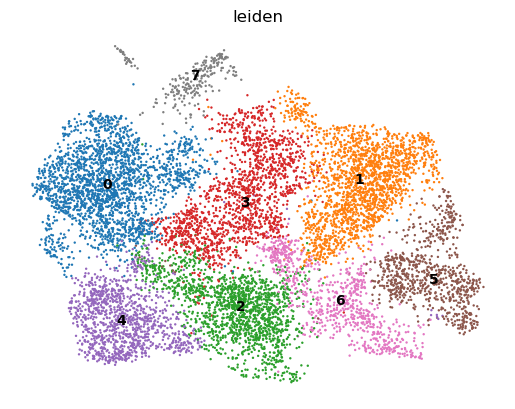

In [64]:
# Ensure order of leiden clustering (str) is available
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
sc.pl.umap(adata, color='leiden', legend_loc='on data', show=True, frameon=False)

In [65]:
# Add annotation to dataset
from utils_biobank_subcut import anno_leiden_dict_epi as anno_leiden_dict

adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
# Order annotation levels by leiden cluster number
adata.obs['anno'] = pd.Categorical(
    adata.obs['anno'],
    categories=[anno_leiden_dict['labels'][f'{i}'] for i in range(len(anno_leiden_dict['labels']))],
    ordered=True
)

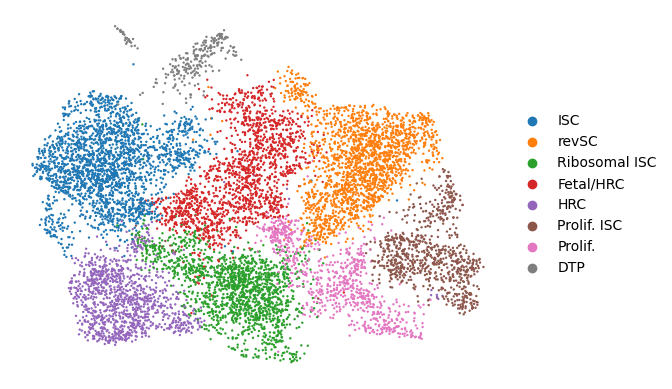

In [66]:
# Annotation UMAP
sc.pl.umap(adata, color=['anno'], frameon=False, title='')

In [67]:
### Infer cell cycle phase
import utils_genelist as genelist

print("Infer cell cycle phase...")
# Get cell-cycle related gene sets
geneset = genelist.get_Tirosh_2016()
sc.tl.score_genes_cell_cycle(adata, 
                        s_genes=genelist.strip_gene_list(geneset['G1/S']), 
                        g2m_genes=genelist.strip_gene_list(geneset['G2/M']))

Infer cell cycle phase...


/omics/groups/OE0285/internal/puschhof/github_projects/TROP2_in_CRC/figures/utils_genelist.py:25: UserWarning: Removed columns containing only NaNs: Unnamed: 7, Unnamed: 8, Unnamed: 9, Unnamed: 10, Unnamed: 11, Unnamed: 12, Unnamed: 13, Unnamed: 14, Unnamed: 15, Unnamed: 16
  warnings.warn(f"Removed columns containing only NaNs: {', '.join(cols_to_remove)}")


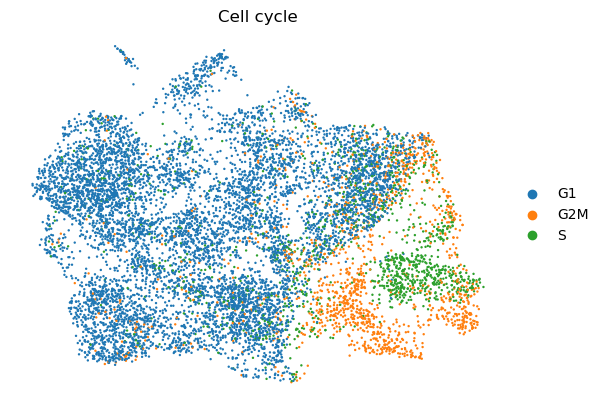

In [68]:
# Cell cycle UMAP
sc.pl.umap(adata, color=['phase'], frameon=False, title='Cell cycle')

## Gene expression UMAP

UMAPs of gene expression patterns:


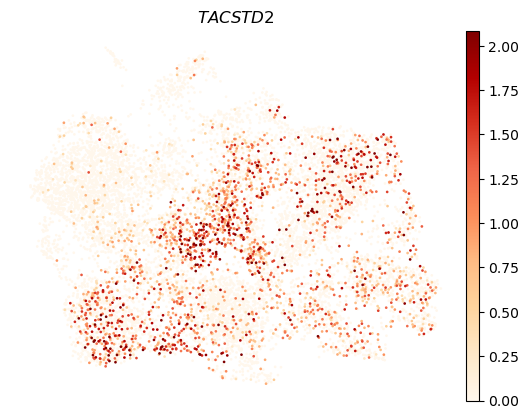

<Figure size 640x480 with 0 Axes>

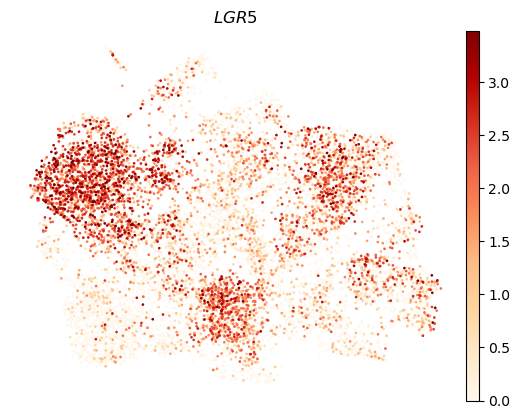

<Figure size 640x480 with 0 Axes>

In [69]:
# Features to plot
features = ['TACSTD2', 'LGR5']

# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot and save UMAPs
    sc.pl.umap(
        adata, 
        color=feature, 
        size=dot_size, 
        cmap='OrRd', 
        vmax=vmax, 
        title=f"$\\it{{{feature}}}$",
        frameon=False
    )
    plt.tight_layout()
    plt.show()

## Gene set activation scores

In [70]:
# Import literature gene sets to adata.uns
from utils import get_gene_sets
print("Importing gene sets into anndata object...")
adata = get_gene_sets(adata, verbose=False)

Importing gene sets into anndata object...


In [71]:
# Compute gene set scores
gs_process = ['score_fetal', 'score_Lgr5', 'score_epiHR']
feature_labels = {
    'score_fetal': 'Fetal',
    'score_Lgr5': 'ISC',
    'score_epiHR': 'EpiHR',
}

import utils_genelist as genelist

gene_sets = adata.uns['gene_sets']
for score_name in gs_process:
    genes = gene_sets[gene_sets['gene_set'] == score_name]['gene']
    adata = genelist.compute_gene_score(adata, genes, score_name=score_name, layer='log1p')

Copying log1p to adata.X for gene score computation...
Computing gene score for score_fetal
Restoring original matrix X.
Copying log1p to adata.X for gene score computation...
Computing gene score for score_Lgr5
Restoring original matrix X.
Copying log1p to adata.X for gene score computation...
Computing gene score for score_epiHR
Restoring original matrix X.


In [ ]:
# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene set scores:")
for feature in gs_process:    
    # Plot and save UMAPs
    sc.pl.umap(adata, color=feature, size=dot_size,
               title=feature_labels[feature], 
               cmap='OrRd', vmax=vmax, frameon=False)
    plt.tight_layout()
    plt.show()

## Stem cell composition

In [ ]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
adata = add_SC_status(adata)

In [ ]:
# Set color code and plot barplot
from utils_treatment_HD4246_SG import color_code
adata = set_color_code(adata, color_code, feature='SC_status')

For the manuscript, the composition plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

/tmp/ipykernel_1379092/379728200.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(groupby)['SC_status']


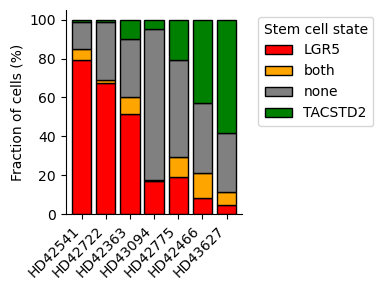

In [ ]:
groupby = 'donor_id'

# Map full donor IDs
from utils import full_donor_id_dict
# from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Sort the DataFrame based on LGR5 levels in descending order
df = df.sort_values(by='LGR5', ascending=False)

# Sort DataFrame based on predefined donor order
# Swap order of HD43094 and HD42775 to match current Figure panel
order_donor_id = [ # order as in current Figure panel
    'HD4254', 'HD4272', 'HD4236', 'HD4309', 'HD4277', 'HD4246', 'HD4362'
]
# Reorder df by 'donor_id' column
df = df.reindex(order_donor_id)

# Barplot 
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(6, 4.5), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([full_donor_id_dict.get(donor, donor) for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stem cell state', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv(f"../data_suppl/{accession}_Fig_01i.csv")
df

SC_status,LGR5,both,none,TACSTD2
donor_id,,,,
HD4254,79.069767,5.852713,13.720930,1.356589
HD4272,67.457306,1.518027,29.648956,1.375712
HD4236,51.297297,8.810811,29.729730,10.162162
HD4309,17.138599,0.298063,77.794337,4.769001
HD4277,19.270833,9.895833,50.000000,20.833333
HD4246,8.444962,12.638323,35.993011,42.923704
HD4362,4.719764,6.588004,30.186824,58.505408


## Comparison TROP2+ vs TROP2- cells 

The association of publicly available gene sets with TROP2+ and TROP2- cell populations has been tested at pseudobulk level. As this has been performed using a different environment, please refer to the notebook *Figure_01_pbulk.ipynb* for this analysis.

# MDO-derived tumors VAKPS and VKPN

## Getting data from arrayExpress: E-MTAB-16835

In [ ]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16835"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset = 'epi',
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16835 in: ../data_arrayExpress/E-MTAB-16835
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16835
      Inferred 2 dataset representations:
      - epi (full prefix: AKPS_KPN_epi)
      - full (full prefix: AKPS_KPN_full)
      Selected dataset for in-memory loading: epi (full prefix: AKPS_KPN_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16835/E-MTAB-16835_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16835/E-MTAB-16835_full.h5ad
      Loading selected dataset from disk: E-MTAB-16835/E-MTAB-16835_epi.h5ad


AnnData object with n_obs × n_vars = 1573 × 18791
    obs: 'sample_id', 'library_id', 'line', 'replicate', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## TEMP: read leiden from metadata file

In [ ]:
file = '../data/AKPS_KPN_epi_metadata.txt'
metadata = pd.read_csv(file, sep='\t', index_col=0)
metadata.head(2)

,sample_id,library_id,line,replicate,leiden,HTO_classification,HTO_classification.global,HTO_maxID
barcode,,,,,,,,
AAACGAACAGCACAGA-1-0,AKPS_NV16_5,S01,AKPS,repl_2,2,AKPS-NV16-mLict-sc-71-Hash-5,Singlet,AKPS-NV16-mLict-sc-71-Hash-5
AAACGCTTCGAGAACG-1-0,AKPS_NV16_4,S01,AKPS,repl_1,6,AKPS-NV16-mLict-sc-70-Hash-4,Singlet,AKPS-NV16-mLict-sc-70-Hash-4


In [ ]:
# Use metadata as adata.obs
adata.obs = metadata
adata.obs.head(2)

,sample_id,library_id,line,replicate,leiden,HTO_classification,HTO_classification.global,HTO_maxID
barcode,,,,,,,,
AAACGAACAGCACAGA-1-0,AKPS_NV16_5,S01,AKPS,repl_2,2,AKPS-NV16-mLict-sc-71-Hash-5,Singlet,AKPS-NV16-mLict-sc-71-Hash-5
AAACGCTTCGAGAACG-1-0,AKPS_NV16_4,S01,AKPS,repl_1,6,AKPS-NV16-mLict-sc-70-Hash-4,Singlet,AKPS-NV16-mLict-sc-70-Hash-4


## UMAP representation

In [ ]:
# Ensure order of leiden clustering (str) is available
adata.obs['leiden'] = adata.obs['leiden'].astype(str)

In [ ]:
# Add annotation to dataset
from utils_VAKPS_VKPN import anno_leiden_dict_epi as anno_leiden_dict

adata.obs['leiden'] = adata.obs['leiden'].astype(str)
adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
# Order annotation levels by leiden cluster number
adata.obs['anno'] = pd.Categorical(
    adata.obs['anno'],
    categories=[anno_leiden_dict['labels'][f'{i}'] for i in range(len(anno_leiden_dict['labels']))],
    ordered=True
)

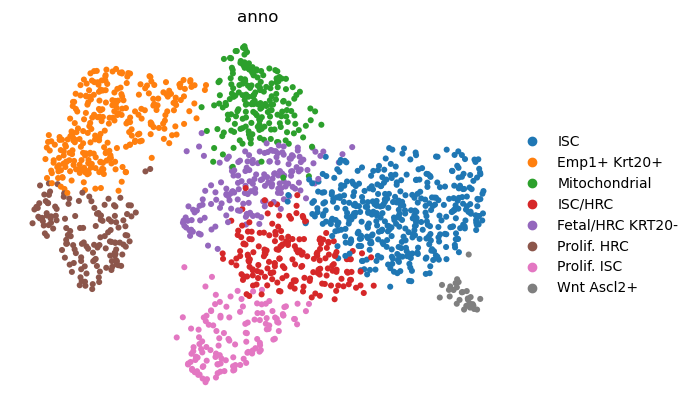

In [ ]:
sc.pl.umap(adata, color='anno', frameon=False, title=None)

## Feature expression on UMAP

UMAPs of gene expression patterns:


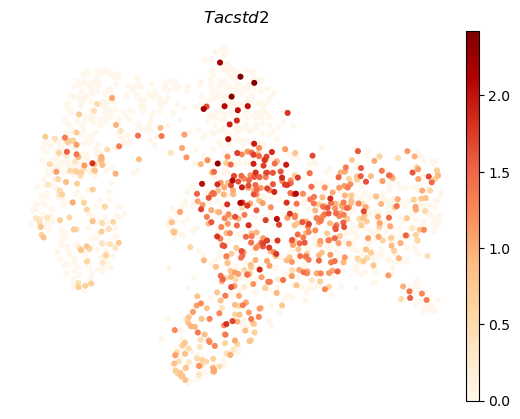

<Figure size 640x480 with 0 Axes>

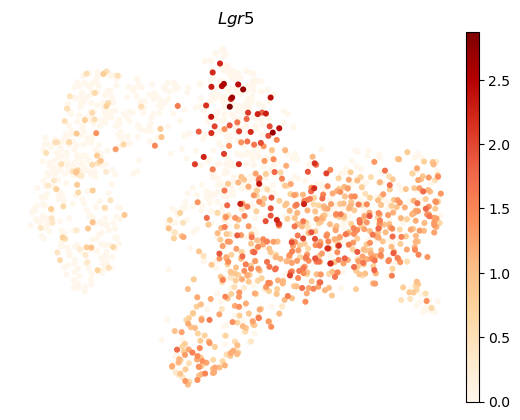

<Figure size 640x480 with 0 Axes>

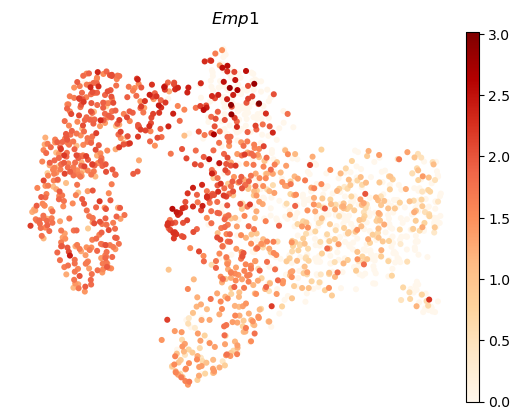

<Figure size 640x480 with 0 Axes>

In [ ]:
# Features to plot
features = ['Tacstd2', 'Lgr5', 'Emp1']

# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot and save UMAPs
    sc.pl.umap(
        adata, 
        color=feature, 
        # size=dot_size, 
        cmap='OrRd', 
        # vmax=vmax, 
        title=f"$\\it{{{feature}}}$",
        frameon=False
    )
    plt.tight_layout()
    plt.show()

## Stem cell composition

In [ ]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
adata = add_SC_status(adata, species="Mm")

In [ ]:
# Set color code and plot barplot
from utils_VAKPS_VKPN import color_code
adata = set_color_code(adata, color_code, feature='SC_status')

For the manuscript, the composition plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

/tmp/ipykernel_1379092/2431829228.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(groupby)['SC_status']


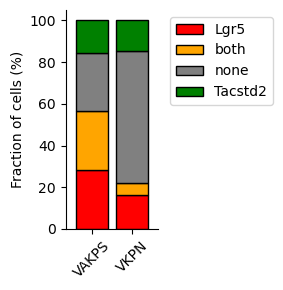

In [ ]:
groupby = 'line'

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Map line identity
line_mapping = {
    'AKPS': 'VAKPS',
    'KPN': 'VKPN',
}
df.index = df.index.map(line_mapping)

# Barplot 
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(3, 3), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.xaxis.set_tick_params(rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv(f"../data_suppl/{accession}_Fig_01m.csv")
df

SC_status,Lgr5,both,none,Tacstd2
line,,,,
VAKPS,28.213978,28.386540,27.868852,15.53063
VKPN,16.183575,5.797101,63.285024,14.73430


# Session info

The analysis above has been performed using a micromamba environment with the following package versions:

In [ ]:
session_info.show()

/omics/groups/OE0285/internal/puschhof/envs/env_funcomics/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
